In [1]:
import qutip as qt
from qutip.qip.circuit import QubitCircuit
import numpy as np
import matplotlib.pyplot as plt

# Make the state

In [2]:
def RXX(phi):
    mat = np.zeros((4, 4), dtype=complex)
    mat[0, 0] = mat[1, 1] = mat[2, 2] = mat[3, 3] = np.cos(phi/2)
    mat[0, 3] = mat[1, 2] = mat[2, 1] = mat[3, 0] = -1j * np.sin(phi/2)
    return qt.Qobj(mat, dims=[[2, 2], [2, 2]])

In [3]:
def output_counterintuitive_XXNNN(phi, phi2, N):
    zero_state = qt.basis(2, 0)
    for _ in range(N-1):
        zero_state = qt.tensor(zero_state, qt.basis(2, 0))
    qc = QubitCircuit(N)
    qc.user_gates = {"RXX": RXX}
    for i in range(N):
        qc.add_gate("SNOT", targets=i)
    for i in range(N-1):
        qc.add_gate("CZ", controls=i, targets=i+1)
    for i in range(2, N-4, 2):
        qc.add_gate("RXX", targets=[i, i+2], arg_value=phi)
    qc.add_gate("RX", targets=[2], arg_value=phi2)
    qc.add_gate("RX", targets=[N-3], arg_value=phi2)
    return qc.run(state=zero_state)

# N = 11

In [4]:
SOP24 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2))
SOP26 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2))
SOP28 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2))
SOP46 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2))
SOP48 =  qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2))
SOP68 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2))
SOP2468 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2))
SOP246 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP248 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz())
SOP268 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz())
SOP468 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz(), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz())
SOP2end = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP4end = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP6end = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP8end = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz())
I = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2))

In [7]:
def logicalX_tworot(betak, betal, SOPkl):
    return np.cos(betak)*np.cos(betal) - SOPkl*np.sin(betak)*np.sin(betal)

def logicalY_tworot(beta, betal, SOPkend, SOPlend):
    return SOPkend*np.sin(beta)*np.cos(betal) + SOPlend*np.cos(beta)*np.sin(betal)

def logicalX_threerot(betak, betal, betam, SOPkl, SOPkm, SOPlm):
    return -SOPkl * np.sin(betak) * np.sin(betal)*np.cos(betam) - SOPkm * np.sin(betak) * np.cos(betal) * np.sin(betam) - SOPlm * np.cos(betak) * np.sin(betal) * np.sin(betam) + np.cos(betak) * np.cos(betal) * np.cos(betam)

def logicalY_threerot(betak, betal, betam, SOPklm, SOPkend, SOPlend, SOPmend):
    return -SOPklm * np.sin(betak) * np.sin(betal) * np.sin(betam) + SOPkend * np.sin(betak) * np.cos(betal) * np.cos(betam) + SOPlend * np.cos(betak) * np.sin(betal) * np.cos(betam) + SOPmend * np.cos(betak) * np.cos(betal) * np.sin(betam)

def logicalX_fourrot(betak, betal, betam, betan, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmn):
    return SOPklmn * np.sin(betak)*np.sin(betal)*np.sin(betam)*np.sin(betan) - SOPkl*np.sin(betak)*np.sin(betal)*np.cos(betam)*np.cos(betan) - SOPkm*np.sin(betak)*np.cos(betal)*np.sin(betam)*np.cos(betan) - SOPkn*np.sin(betak)*np.cos(betal)*np.cos(betam)*np.sin(betan) - SOPlm*np.cos(betak)*np.sin(betal)*np.sin(betam)*np.cos(betan)-SOPln*np.cos(betak)*np.sin(betal)*np.cos(betam)*np.sin(betan)-SOPmn*np.sin(betak)*np.sin(betal)*np.cos(betam)*np.cos(betan) + np.cos(betak)*np.cos(betal)*np.cos(betam)*np.cos(betan)

def logicalY_fourrot(betak, betal, betam, betan, SOPk, SOPl, SOPm, SOPn, SOPklm, SOPkln, SOPkmn, SOPlmn):
    return -SOPklm*np.sin(betak)*np.sin(betal)*np.sin(betam)*np.cos(betan) - SOPkln*np.sin(betak)*np.sin(betal)*np.cos(betam)*np.sin(betan) - SOPkmn*np.sin(betak)*np.cos(betal)*np.sin(betam)*np.sin(betan) + SOPk*np.sin(betak)*np.cos(betal)*np.cos(betam)*np.cos(betan) - SOPlmn*np.cos(betak)*np.sin(betal)*np.sin(betam)*np.sin(betan) + SOPl*np.cos(betak)*np.sin(betal)*np.cos(betam)*np.cos(betan) + SOPm*np.cos(betak)*np.cos(betal)*np.sin(betam)*np.cos(betan) + SOPn*np.cos(betak)*np.cos(betal)*np.cos(betam)*np.sin(betan)


def purity_tworot(betak, betal, SOPkl, SOPkend, SOPlend):
    return (1 - logicalX_tworot(betak, betal, SOPkl)**2 - logicalY_tworot(betak, betal, SOPkend, SOPlend)**2)/2

def purity_threerot(betak, betal, betam, SOPkend, SOPlend, SOPmend, SOPkl, SOPkm, SOPlm, SOPklm):
    return (1 - logicalX_threerot(betak, betal, betam, SOPkl, SOPkm, SOPlm)**2 - logicalY_threerot(betak, betal, betam, SOPklm, SOPkend, SOPlend, SOPmend)**2)/2

def purity_fourrot(betak, betal, betam, betan, SOPk, SOPl, SOPm, SOPn, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklm, SOPkln, SOPkmn, SOPlmn, SOPklmn):
    return (1 - logicalX_fourrot(betak, betal, betam, betan, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmn)**2 - logicalY_fourrot(betak, betal, betam, betan, SOPk, SOPl, SOPm, SOPn, SOPklm, SOPkln, SOPkmn, SOPlmn)**2)/2


def f(Kkl, Kkend):
    if Kkl == 1 and Kkend == 1:
        return 0.5
    else:
        return (Kkl - Kkend**2)/(1 - Kkend**2)

In [8]:
tworot_close_purity_ar = []
tworot_error_purity_ar = []
tworot_far_purity_ar = []
threerot_purity_ar = []
threerot_far_purity_ar = []
fourrot_purity_ar = []
fourrot_purity_ar_2 = []
fourrot_purity_ar_3 = []
fourrot_purity_ar_4 = []
f_ar = []
phi_ar = np.linspace(0, np.pi/2, 200)
phi = np.pi/2
beta = np.pi/2
beta_ar = np.linspace(0, np.pi/2, 200)

for phi in phi_ar:
    state = output_counterintuitive_XXNNN(phi, phi, 11)
    SOP24_val = qt.expect(SOP24, state)
    SOP26_val = qt.expect(SOP26, state)
    SOP28_val = qt.expect(SOP28, state)
    SOP46_val = qt.expect(SOP46, state)
    SOP48_val = qt.expect(SOP48, state)
    SOP68_val = qt.expect(SOP68, state)
    SOP246_val = qt.expect(SOP246, state)
    SOP248_val = qt.expect(SOP248, state)
    SOP268_val = qt.expect(SOP268, state)
    SOP468_val = qt.expect(SOP468, state)
    SOP2468_val = qt.expect(SOP2468, state)
    SOP2end_val = qt.expect(SOP2end, state)
    SOP4end_val = qt.expect(SOP4end, state)
    SOP6end_val = qt.expect(SOP6end, state)
    SOP8end_val = qt.expect(SOP8end, state)
    tworot_close_purity_ar.append(purity_tworot(beta/2, beta/2, SOP24_val, SOP2end_val, SOP4end_val))
    tworot_error_purity_ar.append(purity_tworot(beta/2, -beta/2, SOP24_val, SOP2end_val, SOP4end_val))
    tworot_far_purity_ar.append(purity_tworot(beta/2, beta/2, SOP28_val, SOP2end_val, SOP8end_val))
    threerot_purity_ar.append(purity_threerot(beta/3, beta/3, beta/3, SOP2end_val, SOP4end_val, SOP6end_val, SOP24_val, SOP26_val, SOP46_val, SOP246_val))
    threerot_far_purity_ar.append(purity_threerot(beta/3, beta/3, beta/3, SOP2end_val, SOP4end_val, SOP8end_val, SOP24_val, SOP28_val, SOP48_val, SOP248_val))
    fourrot_purity_ar.append(purity_fourrot(beta/4, beta/4, beta/4, beta/4, SOP2end_val, SOP4end_val, SOP6end_val, SOP8end_val, SOP24_val, SOP26_val, SOP28_val, SOP46_val, SOP48_val, SOP68_val, SOP246_val, SOP248_val, SOP268_val, SOP468_val, SOP2468_val))
    fourrot_purity_ar_2.append(purity_fourrot(beta/4, beta/4, beta/4, -beta/4, SOP2end_val, SOP4end_val, SOP6end_val, SOP8end_val, SOP24_val, SOP26_val, SOP28_val, SOP46_val, SOP48_val, SOP68_val, SOP246_val, SOP248_val, SOP268_val, SOP468_val, SOP2468_val))
    fourrot_purity_ar_3.append(purity_fourrot(beta/4, beta/4, -beta/4, -beta/4, SOP2end_val, SOP4end_val, SOP6end_val, SOP8end_val, SOP24_val, SOP26_val, SOP28_val, SOP46_val, SOP48_val, SOP68_val, SOP246_val, SOP248_val, SOP268_val, SOP468_val, SOP2468_val))
    fourrot_purity_ar_4.append(purity_fourrot(beta/4, -beta/4, -beta/4, beta/4, SOP2end_val, SOP4end_val, SOP6end_val, SOP8end_val, SOP24_val, SOP26_val, SOP28_val, SOP46_val, SOP48_val, SOP68_val, SOP246_val, SOP248_val, SOP268_val, SOP468_val, SOP2468_val))
    # f_ar.append(f(SOP26_val, SOP2end_val))

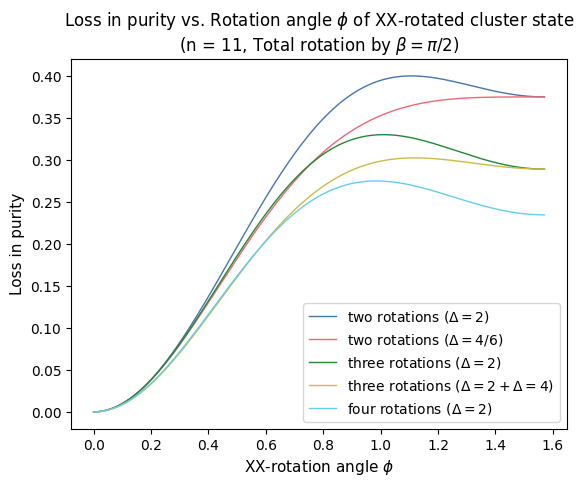

In [10]:
colors = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB"]
plt.plot(phi_ar, np.array(tworot_close_purity_ar), "-", label=r"two rotations ($\Delta=2$)", linewidth=1, color=colors[0])
plt.plot(phi_ar, np.array(tworot_far_purity_ar),  "-", label=r"two rotations ($\Delta=4/6$)", linewidth=1, color=colors[1])
plt.plot(phi_ar, np.array(threerot_purity_ar), "-", label=r"three rotations ($\Delta=2$)", linewidth=1, color=colors[2])
plt.plot(phi_ar, np.array(threerot_far_purity_ar), "-", label=r"three rotations ($\Delta=2 + \Delta= 4$)", linewidth=1, color=colors[3])
plt.plot(phi_ar, np.array(fourrot_purity_ar), "-", label=r"four rotations ($\Delta=2$)", linewidth=1, color=colors[4])
# plt.plot(phi_ar, np.array(fourrot_purity_ar) - np.array(threerot_far_purity_ar), label="four-three")
# plt.plot(phi_ar, np.array(threerot_purity_ar) - np.array(tworot_far_purity_ar), label="three-two")
# plt.axhline(y=0, color="k", linestyle="--")
plt.ylabel("Loss in purity", size=11)
plt.xlabel(r"XX-rotation angle $\phi$", size=11)
plt.legend(loc="best", fontsize=10)
plt.title(r"Loss in purity vs. Rotation angle $\phi$ of XX-rotated cluster state" + "\n" + r"(n = 11, Total rotation by $\beta=\pi/2$)")
plt.savefig("figures/LP11qubitcomparison_jan2026.pdf", bbox_inches = "tight")

In [11]:
# Finding crossover points

difference = np.array(tworot_far_purity_ar)-np.array(threerot_purity_ar)
max = 0
for i in range(len(difference)):
    if difference[i] < 0:
        max = i
print(max)
print(phi_ar[max])

difference = np.array(threerot_far_purity_ar) - np.array(fourrot_purity_ar)
max = 0
for i in range(len(difference)):
    if difference[i] < 0:
        max = i
print(max)
print(phi_ar[max])

96
0.7577710923231662
72
0.5683283192423747


In [90]:
phi = np.pi/4
beta_ar = np.linspace(0, np.pi/2, 1000)

In [91]:
tworot_close_purity_ar = []
tworot_far_purity_ar = []
threerot_purity_ar = []
threerot_far_purity_ar = []
fourrot_purity_ar = []
for beta in beta_ar:
    state = output_counterintuitive_XXNNN(phi, phi, 11)
    SOP24_val = qt.expect(SOP24, state)
    SOP26_val = qt.expect(SOP26, state)
    SOP28_val = qt.expect(SOP28, state)
    SOP46_val = qt.expect(SOP46, state)
    SOP48_val = qt.expect(SOP48, state)
    SOP68_val = qt.expect(SOP68, state)
    SOP246_val = qt.expect(SOP246, state)
    SOP248_val = qt.expect(SOP248, state)
    SOP268_val = qt.expect(SOP268, state)
    SOP468_val = qt.expect(SOP468, state)
    SOP2468_val = qt.expect(SOP2468, state)
    SOP2end_val = qt.expect(SOP2end, state)
    SOP4end_val = qt.expect(SOP4end, state)
    SOP6end_val = qt.expect(SOP6end, state)
    SOP8end_val = qt.expect(SOP8end, state)
    tworot_close_purity_ar.append(purity_tworot(beta/2, beta/2, SOP24_val, SOP2end_val, SOP4end_val))
    tworot_far_purity_ar.append(purity_tworot(beta/2, beta/2, SOP28_val, SOP2end_val, SOP8end_val))
    threerot_purity_ar.append(purity_threerot(beta/3, beta/3, beta/3, SOP2end_val, SOP4end_val, SOP6end_val, SOP24_val, SOP26_val, SOP46_val, SOP246_val))
    threerot_far_purity_ar.append(purity_threerot(beta/3, beta/3, beta/3, SOP2end_val, SOP4end_val, SOP8end_val, SOP24_val, SOP28_val, SOP48_val, SOP248_val))
    fourrot_purity_ar.append(purity_fourrot(beta/4, beta/4, beta/4, beta/4, SOP2end_val, SOP4end_val, SOP6end_val, SOP8end_val, SOP24_val, SOP26_val, SOP28_val, SOP46_val, SOP48_val, SOP68_val, SOP246_val, SOP248_val, SOP268_val, SOP468_val, SOP2468_val))

Text(0.5, 1.0, 'Theory loss in purity vs. Logical rotation angle $\\beta$\ncluster state with $\\phi = \\frac{\\pi}{4}$ NNN-$XX$ rotation')

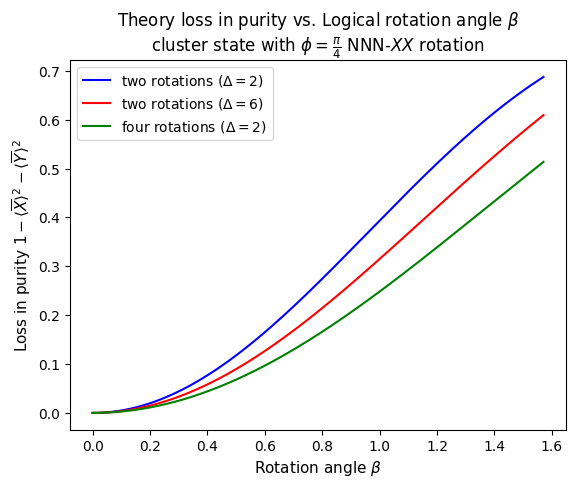

In [92]:
plt.plot(beta_ar, tworot_close_purity_ar, "b-", label=r"two rotations ($\Delta=2$)")
plt.plot(beta_ar, tworot_far_purity_ar, "r-", label=r"two rotations ($\Delta=6$)")
plt.plot(beta_ar, fourrot_purity_ar, "g-", label=r"four rotations ($\Delta=2$)")
plt.ylabel(r"Loss in purity $1 - \langle \overline{X}\rangle^2 - \langle \overline{Y}\rangle^2$", size=11)
plt.xlabel(r"Rotation angle $\beta$", size=11)
plt.legend(loc="best", fontsize=10)
plt.title(r"Theory loss in purity vs. Logical rotation angle $\beta$" + "\n" +  r"cluster state with $\phi = \frac{\pi}{4}$ NNN-$XX$ rotation", size=12)
plt.savefig("figures/CI_purity_theory.pdf")

# Symbolically finding analytic expressions

In [2]:
import sympy as sp

In [216]:
K2, K4, K6, K8, K10, K12, K14, gamma2, gamma4, gamma6, gamma8, gamma10, gamma12, gamma14, beta = sp.symbols("K2, K4, K6, K8, K10, K12, K14, gamma2, gamma4, gamma6, gamma8, gamma10, gamma12, gamma14, beta")

In [30]:
M2 = sp.Matrix([[sp.cos(gamma2), -sp.sin(gamma2)*K2], [sp.sin(gamma2)*K2, sp.cos(gamma2)]])
M4 = sp.Matrix([[sp.cos(gamma4), -sp.sin(gamma4)*K4], [sp.sin(gamma4)*K4, sp.cos(gamma4)]])
M6 = sp.Matrix([[sp.cos(gamma6), -sp.sin(gamma6)*K6], [sp.sin(gamma6)*K6, sp.cos(gamma6)]])
M8 = sp.Matrix([[sp.cos(gamma8), -sp.sin(gamma8)*K8], [sp.sin(gamma8)*K8, sp.cos(gamma8)]])
M10 = sp.Matrix([[sp.cos(gamma10), -sp.sin(gamma10)*K10], [sp.sin(gamma10)*K10, sp.cos(gamma10)]])
M12 = sp.Matrix([[sp.cos(gamma12), -sp.sin(gamma12)*K12], [sp.sin(gamma12)*K12, sp.cos(gamma12)]])
start = sp.Matrix([1, 0])

In [69]:
M2 * start

Matrix([
[   cos(gamma2)],
[K2*sin(gamma2)]])

In [70]:
M4 * M2 * start

Matrix([
[-K2*K4*sin(gamma2)*sin(gamma4) + cos(gamma2)*cos(gamma4)],
[ K2*sin(gamma2)*cos(gamma4) + K4*sin(gamma4)*cos(gamma2)]])

In [71]:
M6 * M4 * M2 * start

Matrix([
[K2*(-K4*sin(gamma4)*cos(gamma6) - K6*sin(gamma6)*cos(gamma4))*sin(gamma2) + (-K4*K6*sin(gamma4)*sin(gamma6) + cos(gamma4)*cos(gamma6))*cos(gamma2)],
[ K2*(-K4*K6*sin(gamma4)*sin(gamma6) + cos(gamma4)*cos(gamma6))*sin(gamma2) + (K4*sin(gamma4)*cos(gamma6) + K6*sin(gamma6)*cos(gamma4))*cos(gamma2)]])

In [72]:
M8 * M6 * M4 * M2 * start

Matrix([
[K2*(-K4*(-K6*K8*sin(gamma6)*sin(gamma8) + cos(gamma6)*cos(gamma8))*sin(gamma4) + (-K6*sin(gamma6)*cos(gamma8) - K8*sin(gamma8)*cos(gamma6))*cos(gamma4))*sin(gamma2) + (K4*(-K6*sin(gamma6)*cos(gamma8) - K8*sin(gamma8)*cos(gamma6))*sin(gamma4) + (-K6*K8*sin(gamma6)*sin(gamma8) + cos(gamma6)*cos(gamma8))*cos(gamma4))*cos(gamma2)],
[  K2*(-K4*(K6*sin(gamma6)*cos(gamma8) + K8*sin(gamma8)*cos(gamma6))*sin(gamma4) + (-K6*K8*sin(gamma6)*sin(gamma8) + cos(gamma6)*cos(gamma8))*cos(gamma4))*sin(gamma2) + (K4*(-K6*K8*sin(gamma6)*sin(gamma8) + cos(gamma6)*cos(gamma8))*sin(gamma4) + (K6*sin(gamma6)*cos(gamma8) + K8*sin(gamma8)*cos(gamma6))*cos(gamma4))*cos(gamma2)]])

In [ ]:
# For my own sanity, after 4 rotations, im just going to impose that all the rotation angles are the same. Else this is terrible.

In [217]:
M2 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K2], [sp.sin(beta)*K2, sp.cos(beta)]])
M4 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K4], [sp.sin(beta)*K4, sp.cos(beta)]])
M6 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K6], [sp.sin(beta)*K6, sp.cos(beta)]])
M8 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K8], [sp.sin(beta)*K8, sp.cos(beta)]])
M10 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K10], [sp.sin(beta)*K10, sp.cos(beta)]])
M12 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K12], [sp.sin(beta)*K12, sp.cos(beta)]])
M14 = sp.Matrix([[sp.cos(beta), -sp.sin(beta)*K14], [sp.sin(beta)*K14, sp.cos(beta)]])
start = sp.Matrix([1, 0])

In [220]:
res = M14 * M12 * M10 * M8 * M6 * M4 * M2 * start
res[1].expand()

-K10*K12*K14*K2*K4*K6*K8*sin(beta)**7 + K10*K12*K14*K2*K4*sin(beta)**5*cos(beta)**2 + K10*K12*K14*K2*K6*sin(beta)**5*cos(beta)**2 + K10*K12*K14*K2*K8*sin(beta)**5*cos(beta)**2 + K10*K12*K14*K4*K6*sin(beta)**5*cos(beta)**2 + K10*K12*K14*K4*K8*sin(beta)**5*cos(beta)**2 + K10*K12*K14*K6*K8*sin(beta)**5*cos(beta)**2 - K10*K12*K14*sin(beta)**3*cos(beta)**4 + K10*K12*K2*K4*K6*sin(beta)**5*cos(beta)**2 + K10*K12*K2*K4*K8*sin(beta)**5*cos(beta)**2 + K10*K12*K2*K6*K8*sin(beta)**5*cos(beta)**2 - K10*K12*K2*sin(beta)**3*cos(beta)**4 + K10*K12*K4*K6*K8*sin(beta)**5*cos(beta)**2 - K10*K12*K4*sin(beta)**3*cos(beta)**4 - K10*K12*K6*sin(beta)**3*cos(beta)**4 - K10*K12*K8*sin(beta)**3*cos(beta)**4 + K10*K14*K2*K4*K6*sin(beta)**5*cos(beta)**2 + K10*K14*K2*K4*K8*sin(beta)**5*cos(beta)**2 + K10*K14*K2*K6*K8*sin(beta)**5*cos(beta)**2 - K10*K14*K2*sin(beta)**3*cos(beta)**4 + K10*K14*K4*K6*K8*sin(beta)**5*cos(beta)**2 - K10*K14*K4*sin(beta)**3*cos(beta)**4 - K10*K14*K6*sin(beta)**3*cos(beta)**4 - K10*K14*K8*

# N = 13

In [ ]:
def logicalX_tworot(beta, SOPkl):
    return np.cos(beta)*np.cos(beta) - SOPkl*np.sin(beta)*np.sin(beta)

def logicalY_tworot(beta, SOPkend, SOPlend):
    return SOPkend*np.sin(beta)*np.cos(beta) + SOPlend*np.cos(beta)*np.sin(beta)

def logicalX_threerot(beta, SOPkl, SOPkm, SOPlm):
    return -SOPkl * np.sin(beta) * np.sin(beta)*np.cos(beta) - SOPkm * np.sin(beta) * np.cos(beta) * np.sin(beta) - SOPlm * np.cos(beta) * np.sin(beta) * np.sin(beta) + np.cos(beta) * np.cos(beta) * np.cos(beta)

def logicalY_threerot(beta, SOPklm, SOPkend, SOPlend, SOPmend):
    return -SOPklm * np.sin(beta) * np.sin(beta) * np.sin(beta) + SOPkend * np.sin(beta) * np.cos(beta) * np.cos(beta) + SOPlend * np.cos(beta) * np.sin(beta) * np.cos(beta) + SOPmend * np.cos(beta) * np.cos(beta) * np.sin(beta)

def logicalX_fourrot(beta, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmn):
    return SOPklmn * np.sin(beta)*np.sin(beta)*np.sin(beta)*np.sin(beta) - SOPkl*np.sin(beta)*np.sin(beta)*np.cos(beta)*np.cos(beta) - SOPkm*np.sin(beta)*np.cos(beta)*np.sin(beta)*np.cos(beta) - SOPkn*np.sin(beta)*np.cos(beta)*np.cos(beta)*np.sin(beta) - SOPlm*np.cos(beta)*np.sin(beta)*np.sin(beta)*np.cos(beta)-SOPln*np.cos(beta)*np.sin(beta)*np.cos(beta)*np.sin(beta)-SOPmn*np.sin(beta)*np.sin(beta)*np.cos(beta)*np.cos(beta) + np.cos(beta)*np.cos(beta)*np.cos(beta)*np.cos(beta)

def logicalY_fourrot(beta, SOPk, SOPl, SOPm, SOPn, SOPklm, SOPkln, SOPkmn, SOPlmn):
    return -SOPklm*np.sin(beta)*np.sin(beta)*np.sin(beta)*np.cos(beta) - SOPkln*np.sin(beta)*np.sin(beta)*np.cos(beta)*np.sin(beta) - SOPkmn*np.sin(beta)*np.cos(beta)*np.sin(beta)*np.sin(beta) + SOPk*np.sin(beta)*np.cos(beta)*np.cos(beta)*np.cos(beta) - SOPlmn*np.cos(beta)*np.sin(beta)*np.sin(beta)*np.sin(beta) + SOPl*np.cos(beta)*np.sin(beta)*np.cos(beta)*np.cos(beta) + SOPm*np.cos(beta)*np.cos(beta)*np.sin(beta)*np.cos(beta) + SOPn*np.cos(beta)*np.cos(beta)*np.cos(beta)*np.sin(beta)


def sin(beta):
    return np.sin(beta)

def cos(beta):
    return np.cos(beta)

def logicalX_fiverot(beta, SOPko, SOPlo, SOPmo, SOPno, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmo, SOPklno, SOPkmno, SOPlmno, SOPklmn):
    return (SOPklmo + SOPklno + SOPkmno + SOPlmno + SOPklmn)*sin(beta)**4*cos(beta) - (SOPko + SOPlo + SOPmo + SOPno+ SOPkl + SOPkm + SOPkn + SOPlm + SOPln + SOPmn)*sin(beta)**2*cos(beta)**3 + cos(beta)**5

def logicalY_fiverot(beta, SOPk, SOPl, SOPm, SOPn, SOPo, SOPklo, SOPkmo, SOPkno, SOPlmo, SOPlno, SOPnmo, SOPklm, SOPkln, SOPkmn, SOPlnm, SOPklmno):
    return SOPklmno * sin(beta)**5 - (SOPklo + SOPkmo + SOPkno + SOPlmo + SOPlno + SOPnmo + SOPklm + SOPkln + SOPkmn + SOPlnm) * sin(beta)**3 * cos(beta)**2 + (SOPk + SOPl + SOPm + SOPn + SOPo) * sin(beta) * cos(beta)**4


def purity_tworot(beta, SOPkend, SOPlend, SOPkl):
    return (1 - logicalX_tworot(beta, SOPkl)**2 - logicalY_tworot(beta, SOPkend, SOPlend)**2)/2

def purity_threerot(beta, SOPkend, SOPlend, SOPmend, SOPkl, SOPkm, SOPlm, SOPklm):
    return (1 - logicalX_threerot(beta, SOPkl, SOPkm, SOPlm)**2 - logicalY_threerot(beta, SOPklm, SOPkend, SOPlend, SOPmend)**2)/2

def purity_fourrot(beta, SOPk, SOPl, SOPm, SOPn, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklm, SOPkln, SOPkmn, SOPlmn, SOPklmn):
    return (1 - logicalX_fourrot(beta, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmn)**2 - logicalY_fourrot(beta, SOPk, SOPl, SOPm, SOPn, SOPklm, SOPkln, SOPkmn, SOPlmn)**2)/2

def purity_fiverot(beta, SOPk, SOPl, SOPm, SOPn, SOPo, SOPko, SOPlo, SOPmo, SOPno, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklo, SOPkmo, SOPkno, SOPlmo, SOPlno, SOPnmo, SOPklm, SOPkln, SOPkmn, SOPlnm, SOPklmo, SOPklno, SOPkmno, SOPlmno, SOPklmn, SOPklmno):
    return (1 - logicalX_fiverot(beta, SOPko, SOPlo, SOPmo, SOPno, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmo, SOPklno, SOPkmno, SOPlmno, SOPklmn)**2 - logicalY_fiverot(beta, SOPk, SOPl, SOPm, SOPn, SOPo, SOPklo, SOPkmo, SOPkno, SOPlmo, SOPlno, SOPnmo, SOPklm, SOPkln, SOPkmn, SOPlnm, SOPklmno)**2)/2

In [207]:
SOP2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP4 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP6 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP8 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP10 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz())
I = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2))

SOP24 = SOP2*SOP4
SOP26 = SOP2*SOP6
SOP28 = SOP2*SOP8
SOP210 = SOP2*SOP10
SOP46 = SOP4*SOP6
SOP48 = SOP4*SOP8
SOP410 = SOP4*SOP10
SOP68 = SOP6*SOP8
SOP610 = SOP6*SOP10
SOP810 = SOP8*SOP10

SOP246 = SOP2*SOP4*SOP6
SOP248 = SOP2*SOP4*SOP8
SOP2410 = SOP2*SOP4*SOP10
SOP268 = SOP2*SOP6*SOP8
SOP2610 = SOP2*SOP6*SOP10
SOP2810 = SOP2*SOP8*SOP10
SOP468 = SOP4*SOP6*SOP8
SOP4610 = SOP4*SOP6*SOP10
SOP4810 = SOP4*SOP8*SOP10
SOP6810 = SOP6*SOP8*SOP10

SOP2468 = SOP2 * SOP4 * SOP6 * SOP8
SOP24610 = SOP2 * SOP4 * SOP6 * SOP10
SOP24810 = SOP2 * SOP4 * SOP8 * SOP10
SOP26810 = SOP2 * SOP6 * SOP8 * SOP10
SOP46810 = SOP4 * SOP6 * SOP8 * SOP10

SOP246810 = SOP2 * SOP4 * SOP6 * SOP8 * SOP10

In [208]:
tworot_purity_ar = []
threerot_purity_ar = []
fourrot_purity_ar = []
fiverot_purity_ar = []
phi_ar = np.linspace(0, np.pi/2, 200)
beta = np.pi/2
for phi in phi_ar:
    state = output_counterintuitive_XXNNN(phi, phi, 13)

    SOP2_val = qt.expect(SOP2, state)
    SOP4_val = qt.expect(SOP4, state)
    SOP6_val = qt.expect(SOP6, state)
    SOP8_val = qt.expect(SOP8, state)
    SOP10_val = qt.expect(SOP10, state)

    SOP24_val = qt.expect(SOP24, state)
    SOP26_val = qt.expect(SOP26, state)
    SOP28_val = qt.expect(SOP28, state)
    SOP210_val = qt.expect(SOP210, state)
    SOP46_val = qt.expect(SOP46, state)
    SOP48_val = qt.expect(SOP48, state)
    SOP410_val = qt.expect(SOP410, state)
    SOP68_val = qt.expect(SOP68, state)
    SOP610_val = qt.expect(SOP610, state)
    SOP810_val = qt.expect(SOP810, state)

    SOP246_val = qt.expect(SOP246, state)
    SOP248_val = qt.expect(SOP248, state)
    SOP2410_val = qt.expect(SOP2410, state)
    SOP268_val = qt.expect(SOP268, state)
    SOP2610_val = qt.expect(SOP2610, state)
    SOP2810_val = qt.expect(SOP2810, state)
    SOP468_val = qt.expect(SOP468, state)
    SOP4610_val = qt.expect(SOP4610, state)
    SOP4810_val = qt.expect(SOP4810, state)
    SOP6810_val = qt.expect(SOP6810, state)


    SOP2468_val = qt.expect(SOP2468, state)
    SOP24610_val = qt.expect(SOP24610, state)
    SOP24810_val = qt.expect(SOP24810, state)
    SOP26810_val = qt.expect(SOP26810, state)
    SOP46810_val = qt.expect(SOP46810, state)

    SOP246810_val = qt.expect(SOP246810, state)

    tworot_purity_ar.append(purity_tworot(beta/2, SOP2_val, SOP10_val, SOP210_val))
    threerot_purity_ar.append(purity_threerot(beta/3, SOP2_val, SOP6_val, SOP10_val, SOP26_val, SOP210_val, SOP610_val, SOP2610_val))
    fourrot_purity_ar.append(purity_fourrot(beta/4, SOP2_val, SOP4_val, SOP6_val, SOP10_val, SOP24_val, SOP26_val, SOP210_val, SOP46_val, SOP410_val, SOP610_val, SOP246_val, SOP2410_val, SOP2610_val, SOP4610_val, SOP24610_val))
    
    fiverot_purity_ar.append(purity_fiverot(beta/5, SOP2_val, SOP4_val, SOP6_val, SOP8_val, SOP10_val, SOP24_val, SOP26_val, SOP28_val, SOP210_val, SOP46_val, SOP48_val, SOP410_val, SOP68_val, SOP610_val, SOP810_val, SOP246_val, SOP248_val, SOP2410_val, SOP268_val, SOP2610_val, SOP2810_val, SOP468_val, SOP4610_val, SOP4810_val, SOP6810_val, SOP2468_val, SOP24610_val, SOP24810_val, SOP26810_val, SOP46810_val, SOP246810_val))

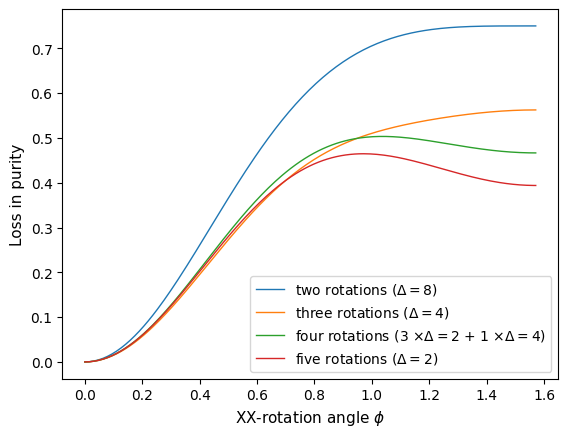

In [209]:
plt.plot(phi_ar, tworot_purity_ar, "-", label=r"two rotations ($\Delta=8$)", linewidth=1)
plt.plot(phi_ar, threerot_purity_ar,  "-", label=r"three rotations ($\Delta=4$)", linewidth=1)
plt.plot(phi_ar, fourrot_purity_ar, "-", label=r"four rotations (3 $\times \Delta=2$ + 1 $\times \Delta = 4$)", linewidth=1)
plt.plot(phi_ar, fiverot_purity_ar, "-", label=r"five rotations ($\Delta=2$)", linewidth=1)
plt.ylabel("Loss in purity", size=11)
plt.xlabel(r"XX-rotation angle $\phi$", size=11)
plt.legend(loc="best", fontsize=10)
# plt.title(r"Loss in purity vs. NNN XX-rotation angle $\phi$ on cluster state" + "\n" + r"Fixed logical rotation $\beta=\pi/2$")

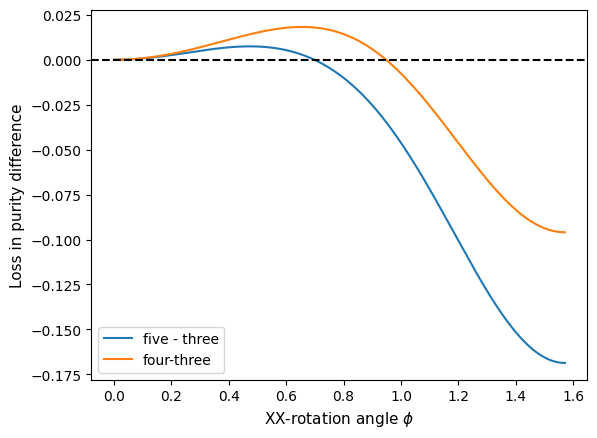

In [210]:
plt.plot(phi_ar, (np.array(fiverot_purity_ar) - np.array(threerot_purity_ar)), label="five - three")
plt.plot(phi_ar, (np.array(fourrot_purity_ar) - np.array(threerot_purity_ar)), label="four-three")
plt.axhline(y=0, color="k", linestyle="--")
plt.ylabel("Loss in purity difference", size=11)
plt.xlabel(r"XX-rotation angle $\phi$", size=11)
plt.legend(loc="best", fontsize=10)

# N = 17

In [12]:
SOP2 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP4 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP6 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP8 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP10 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP12 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.qeye(2), qt.sigmax(), qt.sigmaz())
SOP14 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.sigmaz(), qt.sigmax(), qt.sigmaz())
I = qt.tensor(qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2), qt.qeye(2))


# 2body
SOP24 = SOP2*SOP4
SOP26 = SOP2*SOP6
SOP28 = SOP2*SOP8
SOP210 = SOP2*SOP10
SOP212 = SOP2 * SOP12
SOP214 = SOP2 * SOP14
SOP46 = SOP4*SOP6
SOP48 = SOP4*SOP8
SOP410 = SOP4*SOP10
SOP412 = SOP4*SOP12
SOP414 = SOP4*SOP14
SOP68 = SOP6*SOP8
SOP610 = SOP6*SOP10
SOP612 = SOP6*SOP12
SOP614 = SOP6*SOP14
SOP810 = SOP8*SOP10
SOP812 = SOP8*SOP12
SOP814 = SOP8*SOP14
SOP1012 = SOP10*SOP12
SOP1014 = SOP10*SOP14
SOP1214 = SOP12*SOP14

# 3body
SOP246 = SOP2*SOP4*SOP6
SOP248 = SOP2*SOP4*SOP8
SOP2410 = SOP2*SOP4*SOP10
SOP2412 = SOP2*SOP4*SOP12
SOP2414 = SOP2*SOP4*SOP14
SOP268 = SOP2*SOP6*SOP8
SOP2610 = SOP2*SOP6*SOP10
SOP2612 = SOP2*SOP6*SOP12
SOP2614 = SOP2*SOP6*SOP14
SOP2810 = SOP2*SOP8*SOP10
SOP2812 = SOP2*SOP8*SOP12
SOP2814 = SOP2*SOP8*SOP14
SOP21012 = SOP2*SOP10*SOP12
SOP21014 = SOP2*SOP10*SOP14
SOP21214 = SOP2*SOP12*SOP14
SOP468 = SOP4*SOP6*SOP8
SOP4610 = SOP4*SOP6*SOP10
SOP4612 = SOP4*SOP6*SOP12
SOP4614 = SOP4*SOP6*SOP14
SOP4810 = SOP4*SOP8*SOP10
SOP4812 = SOP4*SOP8*SOP12
SOP4814 = SOP4*SOP8*SOP14
SOP41012 = SOP4*SOP10*SOP12
SOP41014 = SOP4*SOP10*SOP14
SOP41214 = SOP4*SOP12*SOP14
SOP6810 = SOP6*SOP8*SOP10
SOP6812 = SOP6*SOP8*SOP12
SOP6814 = SOP6*SOP8*SOP14
SOP61012 = SOP6*SOP10*SOP12
SOP61014 = SOP6*SOP10*SOP14
SOP61214 = SOP6*SOP12*SOP14
SOP81012 = SOP8*SOP10*SOP12
SOP81014 = SOP8*SOP10*SOP14
SOP81214 = SOP8*SOP12*SOP14
SOP101214 = SOP10*SOP12*SOP14

# 4body
SOP2468 = SOP2 * SOP4 * SOP6 * SOP8
SOP24610 = SOP2 * SOP4 * SOP6 * SOP10
SOP24612 = SOP2 * SOP4 * SOP6 * SOP12
SOP24614 = SOP2 * SOP4 * SOP6 * SOP14
SOP24810 = SOP2 * SOP4 * SOP8 * SOP10
SOP24812 = SOP2 * SOP4 * SOP8 * SOP12
SOP24814 = SOP2 * SOP4 * SOP8 * SOP14
SOP241012 = SOP2 * SOP4 * SOP10 * SOP12
SOP241014 = SOP2 * SOP4 * SOP10 * SOP14
SOP241214 = SOP2 * SOP4 * SOP12 * SOP14
SOP26810 = SOP2 * SOP6 * SOP8 * SOP10
SOP26812 = SOP2 * SOP6 * SOP8 * SOP12
SOP26814 = SOP2 * SOP6 * SOP8 * SOP14
SOP261012 = SOP2 * SOP6 * SOP10 * SOP12
SOP261014 = SOP2 * SOP6 * SOP12 * SOP14
SOP261214 = SOP2 * SOP6 * SOP12 * SOP14
SOP281012 = SOP2 * SOP8 * SOP10 * SOP12
SOP281014 = SOP2 * SOP8 * SOP10 * SOP14
SOP281214 = SOP2 * SOP8 * SOP12 * SOP14
SOP2101214 = SOP2 * SOP10 * SOP12 * SOP14
SOP46810 = SOP4 * SOP6 * SOP8 * SOP10
SOP46812 = SOP4 * SOP6 * SOP8 * SOP12
SOP46814 = SOP4 * SOP6 * SOP8 * SOP14
SOP461012 = SOP4 * SOP6 * SOP10 * SOP12
SOP461014 = SOP4 * SOP6 * SOP10 * SOP14
SOP461214 = SOP4 * SOP6 * SOP12 * SOP14 
SOP481012 = SOP4 * SOP8 * SOP10 * SOP12
SOP481014 = SOP4 * SOP8 * SOP10 * SOP14
SOP481214 = SOP4 * SOP8 * SOP12 * SOP14
SOP4101214 = SOP4 * SOP10 * SOP12 * SOP14
SOP681012 = SOP6 * SOP8 * SOP10 * SOP12
SOP681014 = SOP6 * SOP8 * SOP10 * SOP14
SOP681214 = SOP6 * SOP8 * SOP12 * SOP14
SOP6101214 = SOP6 * SOP10 * SOP12 * SOP14
SOP8101214 = SOP8 * SOP10 * SOP12 * SOP14

# 5body
SOP246810 = SOP2 * SOP4 * SOP6 * SOP8 * SOP10
SOP246812 = SOP2 * SOP4 * SOP6 * SOP8 * SOP12
SOP246814 = SOP2 * SOP4 * SOP6 * SOP8 * SOP14
SOP2461012 = SOP2 * SOP4 * SOP6 * SOP10 * SOP12
SOP2461014 = SOP2 * SOP4 * SOP6 * SOP10 * SOP14
SOP2461214 = SOP2 * SOP4 * SOP6 * SOP12 * SOP14
SOP2481012 = SOP2 * SOP4 * SOP8 * SOP10 * SOP12
SOP2481014 = SOP2 * SOP4 * SOP8 * SOP10 * SOP14
SOP2481214 = SOP2 * SOP4 * SOP8 * SOP12 * SOP14
SOP24101214 = SOP2 * SOP4 * SOP10 * SOP12 * SOP14
SOP2681012 = SOP2 * SOP6 * SOP8 * SOP10 * SOP12
SOP2681014 = SOP2 * SOP6 * SOP8 * SOP10 * SOP14
SOP2681214 = SOP2 * SOP6 * SOP8 * SOP12 * SOP14
SOP26101214 = SOP2 * SOP6 * SOP10 * SOP12 * SOP14
SOP28101214 = SOP2 * SOP8 * SOP10 * SOP12 * SOP14
SOP4681012 = SOP4 * SOP6 * SOP8 * SOP10 * SOP12
SOP4681014 = SOP4 * SOP6 * SOP8 * SOP10 * SOP14
SOP4681214 = SOP4 * SOP6 * SOP8 * SOP12 * SOP14
SOP46101214 = SOP4 * SOP6 * SOP10 * SOP12 * SOP14
SOP48101214 = SOP4 * SOP8 * SOP10 * SOP12 * SOP14
SOP68101214 = SOP6 * SOP8 * SOP10 * SOP12 * SOP14

# 6body
SOP24681012 = SOP2 * SOP4 * SOP6 * SOP8 * SOP10 * SOP12
SOP24681014 = SOP2 * SOP4 * SOP6 * SOP8 * SOP10 * SOP14
SOP24681214 = SOP2 * SOP4 * SOP6 * SOP8 * SOP12 * SOP14
SOP246101214 = SOP2 * SOP4 * SOP6 * SOP10 * SOP12 * SOP14
SOP248101214 = SOP2 * SOP4 * SOP8 * SOP10 * SOP12 * SOP14
SOP268101214 = SOP2 * SOP6 * SOP8 * SOP10 * SOP12 * SOP14
SOP468101214 = SOP4 * SOP6 * SOP8 * SOP10 * SOP12 * SOP14

# 7body
SOP2468101214 = SOP2 * SOP4 * SOP6 * SOP8 * SOP10 * SOP12 * SOP14

In [13]:
def logicalX_tworot(beta, SOPkl):
    return np.cos(beta)*np.cos(beta) - SOPkl*np.sin(beta)*np.sin(beta)

def logicalY_tworot(beta, SOPkend, SOPlend):
    return SOPkend*np.sin(beta)*np.cos(beta) + SOPlend*np.cos(beta)*np.sin(beta)

def logicalX_threerot(beta, SOPkl, SOPkm, SOPlm):
    return -SOPkl * np.sin(beta) * np.sin(beta)*np.cos(beta) - SOPkm * np.sin(beta) * np.cos(beta) * np.sin(beta) - SOPlm * np.cos(beta) * np.sin(beta) * np.sin(beta) + np.cos(beta) * np.cos(beta) * np.cos(beta)

def logicalY_threerot(beta, SOPklm, SOPkend, SOPlend, SOPmend):
    return -SOPklm * np.sin(beta) * np.sin(beta) * np.sin(beta) + SOPkend * np.sin(beta) * np.cos(beta) * np.cos(beta) + SOPlend * np.cos(beta) * np.sin(beta) * np.cos(beta) + SOPmend * np.cos(beta) * np.cos(beta) * np.sin(beta)

def logicalX_fourrot(beta, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmn):
    return SOPklmn * np.sin(beta)*np.sin(beta)*np.sin(beta)*np.sin(beta) - SOPkl*np.sin(beta)*np.sin(beta)*np.cos(beta)*np.cos(beta) - SOPkm*np.sin(beta)*np.cos(beta)*np.sin(beta)*np.cos(beta) - SOPkn*np.sin(beta)*np.cos(beta)*np.cos(beta)*np.sin(beta) - SOPlm*np.cos(beta)*np.sin(beta)*np.sin(beta)*np.cos(beta)-SOPln*np.cos(beta)*np.sin(beta)*np.cos(beta)*np.sin(beta)-SOPmn*np.sin(beta)*np.sin(beta)*np.cos(beta)*np.cos(beta) + np.cos(beta)*np.cos(beta)*np.cos(beta)*np.cos(beta)

def logicalY_fourrot(beta, SOPk, SOPl, SOPm, SOPn, SOPklm, SOPkln, SOPkmn, SOPlmn):
    return -SOPklm*np.sin(beta)*np.sin(beta)*np.sin(beta)*np.cos(beta) - SOPkln*np.sin(beta)*np.sin(beta)*np.cos(beta)*np.sin(beta) - SOPkmn*np.sin(beta)*np.cos(beta)*np.sin(beta)*np.sin(beta) + SOPk*np.sin(beta)*np.cos(beta)*np.cos(beta)*np.cos(beta) - SOPlmn*np.cos(beta)*np.sin(beta)*np.sin(beta)*np.sin(beta) + SOPl*np.cos(beta)*np.sin(beta)*np.cos(beta)*np.cos(beta) + SOPm*np.cos(beta)*np.cos(beta)*np.sin(beta)*np.cos(beta) + SOPn*np.cos(beta)*np.cos(beta)*np.cos(beta)*np.sin(beta)


def sin(beta):
    return np.sin(beta)

def cos(beta):
    return np.cos(beta)

def logicalX_fiverot(beta, SOPko, SOPlo, SOPmo, SOPno, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmo, SOPklno, SOPkmno, SOPlmno, SOPklmn):
    return (SOPklmo + SOPklno + SOPkmno + SOPlmno + SOPklmn)*sin(beta)**4*cos(beta) - (SOPko + SOPlo + SOPmo + SOPno+ SOPkl + SOPkm + SOPkn + SOPlm + SOPln + SOPmn)*sin(beta)**2*cos(beta)**3 + cos(beta)**5

def logicalY_fiverot(beta, SOPk, SOPl, SOPm, SOPn, SOPo, SOPklo, SOPkmo, SOPkno, SOPlmo, SOPlno, SOPnmo, SOPklm, SOPkln, SOPkmn, SOPlnm, SOPklmno):
    return SOPklmno * sin(beta)**5 - (SOPklo + SOPkmo + SOPkno + SOPlmo + SOPlno + SOPnmo + SOPklm + SOPkln + SOPkmn + SOPlnm) * sin(beta)**3 * cos(beta)**2 + (SOPk + SOPl + SOPm + SOPn + SOPo) * sin(beta) * cos(beta)**4


def logicalX_sevenrot(beta, twobs, fourbs, sixbs):
    return cos(beta)**7 - np.sum(twobs) * sin(beta)**2*cos(beta)**5 + np.sum(fourbs) * sin(beta)**4 * cos(beta)**3 - np.sum(sixbs)*sin(beta)**6*cos(beta)

def logicalY_sevenrot(beta, onebs, threebs, fivebs, sevenbs):
    return  -np.sum(sevenbs) * sin(beta)**7 + np.sum(fivebs) * sin(beta)**5 * cos(beta)**2 - np.sum(threebs) * sin(beta)**3 * cos(beta)**4 + np.sum(onebs) * sin(beta) * cos(beta)**6


def purity_tworot(beta, SOPkend, SOPlend, SOPkl):
    return (1 - logicalX_tworot(beta, SOPkl)**2 - logicalY_tworot(beta, SOPkend, SOPlend)**2)/2

def purity_threerot(beta, SOPkend, SOPlend, SOPmend, SOPkl, SOPkm, SOPlm, SOPklm):
    return (1 - logicalX_threerot(beta, SOPkl, SOPkm, SOPlm)**2 - logicalY_threerot(beta, SOPklm, SOPkend, SOPlend, SOPmend)**2)/2

def purity_fourrot(beta, SOPk, SOPl, SOPm, SOPn, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklm, SOPkln, SOPkmn, SOPlmn, SOPklmn):
    return (1 - logicalX_fourrot(beta, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmn)**2 - logicalY_fourrot(beta, SOPk, SOPl, SOPm, SOPn, SOPklm, SOPkln, SOPkmn, SOPlmn)**2)/2

def purity_fiverot(beta, SOPk, SOPl, SOPm, SOPn, SOPo, SOPko, SOPlo, SOPmo, SOPno, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklo, SOPkmo, SOPkno, SOPlmo, SOPlno, SOPnmo, SOPklm, SOPkln, SOPkmn, SOPlnm, SOPklmo, SOPklno, SOPkmno, SOPlmno, SOPklmn, SOPklmno):
    return (1 - logicalX_fiverot(beta, SOPko, SOPlo, SOPmo, SOPno, SOPkl, SOPkm, SOPkn, SOPlm, SOPln, SOPmn, SOPklmo, SOPklno, SOPkmno, SOPlmno, SOPklmn)**2 - logicalY_fiverot(beta, SOPk, SOPl, SOPm, SOPn, SOPo, SOPklo, SOPkmo, SOPkno, SOPlmo, SOPlno, SOPnmo, SOPklm, SOPkln, SOPkmn, SOPlnm, SOPklmno)**2)/2

def purity_sevenrot(beta, onebs, twobs, threebs, fourbs, fivebs, sixbs, sevenbs):
    return (1 - logicalX_sevenrot(beta, twobs, fourbs, sixbs)**2 - logicalY_sevenrot(beta, onebs, threebs, fivebs, sevenbs)**2)/2

In [14]:
threerot_times2_purity_ar = []
fourrot_times2_purity_ar = []
phi_ar = np.linspace(0, np.pi/2, 200)
beta = np.pi/2
for phi in phi_ar:
    state = output_counterintuitive_XXNNN(phi, phi, 17)
    # 1body
    SOP2_val = qt.expect(SOP2, state)
    SOP4_val = qt.expect(SOP4, state)
    SOP6_val = qt.expect(SOP6, state)
    SOP8_val = qt.expect(SOP8, state)
    SOP10_val = qt.expect(SOP10, state)
    SOP12_val = qt.expect(SOP12, state)
    SOP14_val = qt.expect(SOP14, state)

    onebs = np.array([SOP2_val, SOP4_val, SOP6_val, SOP8_val, SOP10_val, SOP12_val, SOP14_val])

    # 2body
    SOP24_val = qt.expect(SOP24, state)
    SOP26_val = qt.expect(SOP26, state)
    SOP28_val = qt.expect(SOP28, state)
    SOP210_val = qt.expect(SOP210, state)
    SOP212_val = qt.expect(SOP212, state)
    SOP214_val = qt.expect(SOP214, state)
    SOP46_val = qt.expect(SOP46, state)
    SOP48_val = qt.expect(SOP48, state)
    SOP410_val = qt.expect(SOP410, state)
    SOP412_val = qt.expect(SOP412, state)
    SOP414_val = qt.expect(SOP414, state)
    SOP68_val = qt.expect(SOP68, state)
    SOP610_val = qt.expect(SOP610, state)
    SOP612_val = qt.expect(SOP612, state)
    SOP614_val = qt.expect(SOP614, state)
    SOP810_val = qt.expect(SOP810, state)
    SOP812_val = qt.expect(SOP812, state)
    SOP814_val = qt.expect(SOP814, state)
    SOP1012_val = qt.expect(SOP1012, state)
    SOP1014_val = qt.expect(SOP1014, state)
    SOP1214_val = qt.expect(SOP1214, state)

    twobs = np.array([SOP24_val, SOP26_val, SOP28_val, SOP210_val, SOP212_val, SOP214_val, SOP46_val, SOP48_val, SOP410_val, SOP412_val, SOP414_val, SOP68_val, SOP610_val, SOP612_val, SOP614_val, SOP810_val, SOP812_val, SOP814_val, SOP1012_val, SOP1014_val, SOP1214_val])

    # 3body
    SOP246_val = qt.expect(SOP246, state)
    SOP248_val = qt.expect(SOP248, state)
    SOP2410_val = qt.expect(SOP2410, state)
    SOP2412_val = qt.expect(SOP2412, state)
    SOP2414_val = qt.expect(SOP2414, state)
    SOP268_val = qt.expect(SOP268, state)
    SOP2610_val = qt.expect(SOP2610, state)
    SOP2612_val = qt.expect(SOP2612, state)
    SOP2614_val = qt.expect(SOP2614, state)
    SOP2810_val = qt.expect(SOP2810, state)
    SOP2812_val = qt.expect(SOP2812, state)
    SOP2814_val = qt.expect(SOP2814, state)
    SOP21012_val = qt.expect(SOP21012, state)
    SOP21014_val = qt.expect(SOP21014, state)
    SOP21214_val = qt.expect(SOP21214, state)
    SOP468_val = qt.expect(SOP468, state)
    SOP4610_val = qt.expect(SOP4610, state)
    SOP4612_val = qt.expect(SOP4612, state)
    SOP4614_val = qt.expect(SOP4614, state)  
    SOP4810_val = qt.expect(SOP4810, state)
    SOP4812_val = qt.expect(SOP4812, state)
    SOP4814_val = qt.expect(SOP4814, state)
    SOP41012_val = qt.expect(SOP41012, state)
    SOP41014_val = qt.expect(SOP41014, state)
    SOP41214_val = qt.expect(SOP41214, state)
    SOP6810_val = qt.expect(SOP6810, state)
    SOP6812_val = qt.expect(SOP6812, state)
    SOP6814_val = qt.expect(SOP6814, state)
    SOP61016_val = qt.expect(SOP61012, state)
    SOP61014_val = qt.expect(SOP61014, state)
    SOP61214_val = qt.expect(SOP61214, state)
    SOP81012_val = qt.expect(SOP81012, state)
    SOP81014_val = qt.expect(SOP81014, state)
    SOP81214_val = qt.expect(SOP81214, state)
    SOP101214_val = qt.expect(SOP101214, state)
    threebs = np.array([SOP246_val, SOP248_val, SOP2410_val, SOP2412_val, SOP2414_val, SOP268_val, SOP2610_val, SOP2612_val, SOP2614_val, SOP2810_val, SOP2812_val, SOP2814_val, SOP21012_val, SOP21014_val, SOP21214_val, SOP468_val, SOP4610_val, SOP4612_val, SOP4614_val, SOP4810_val, SOP4812_val, SOP4814_val, SOP41012_val, SOP41014_val, SOP41214_val, SOP6810_val, SOP6812_val, SOP6814_val, SOP61016_val, SOP61014_val, SOP61214_val, SOP81012_val, SOP81014_val, SOP81214_val, SOP101214_val])

    # 4body
    SOP2468_val = qt.expect(SOP2468, state)
    SOP24610_val = qt.expect(SOP24610, state)
    SOP24612_val = qt.expect(SOP24612, state)
    SOP24614_val = qt.expect(SOP24614, state)
    SOP24810_val = qt.expect(SOP24810, state)
    SOP24812_val = qt.expect(SOP24812, state)
    SOP24814_val = qt.expect(SOP24814, state)
    SOP241012_val = qt.expect(SOP241012, state)
    SOP241014_val = qt.expect(SOP241014, state)
    SOP241214_val = qt.expect(SOP241214, state)
    SOP26810_val = qt.expect(SOP26810, state)
    SOP26812_val = qt.expect(SOP26812, state)
    SOP26814_val = qt.expect(SOP26814, state)
    SOP261012_val = qt.expect(SOP261012, state)
    SOP261014_val = qt.expect(SOP261014, state)
    SOP261214_val = qt.expect(SOP261214, state)
    SOP281012_val = qt.expect(SOP281012, state)
    SOP281014_val = qt.expect(SOP281014, state)
    SOP281214_val = qt.expect(SOP281214, state)
    SOP2101214_val = qt.expect(SOP2101214, state)
    SOP46810_val = qt.expect(SOP46810, state)
    SOP46812_val = qt.expect(SOP46812, state)
    SOP46814_val = qt.expect(SOP46814, state)
    SOP461012_val = qt.expect(SOP461012, state)
    SOP461014_val = qt.expect(SOP461014, state)
    SOP461214_val = qt.expect(SOP461214, state)
    SOP481012_val = qt.expect(SOP481012, state)
    SOP481014_val = qt.expect(SOP481014, state)
    SOP481214_val = qt.expect(SOP481214, state)
    SOP4101214_val = qt.expect(SOP4101214, state)
    SOP681012_val = qt.expect(SOP681012, state)
    SOP681014_val = qt.expect(SOP681014, state)
    SOP681214_val = qt.expect(SOP681214, state)
    SOP6101214_val = qt.expect(SOP6101214, state)
    SOP8101214_val = qt.expect(SOP8101214, state)
    fourbs = np.array([SOP2468_val, SOP24610_val, SOP24612_val, SOP24614_val, SOP24810_val, SOP24812_val, SOP24814_val, SOP241012_val, SOP241014_val, SOP241214_val, SOP26810_val, SOP26812_val, SOP26814_val, SOP261012_val, SOP261014_val, SOP261214_val, SOP281012_val, SOP281014_val, SOP281214_val, SOP2101214_val, SOP46810_val, SOP46812_val, SOP46814_val, SOP461012_val, SOP461014_val,  SOP461214_val, SOP481012_val, SOP481014_val, SOP481214_val, SOP4101214_val, SOP681012_val, SOP681014_val, SOP681214_val, SOP6101214_val, SOP8101214_val])

    # 5body
    SOP246810_val = qt.expect(SOP246810, state)
    SOP246812_val = qt.expect(SOP246812, state)
    SOP246814_val = qt.expect(SOP246814, state)
    SOP2461012_val = qt.expect(SOP2461012, state)
    SOP2461014_val = qt.expect(SOP2461014, state)
    SOP2461214_val = qt.expect(SOP2461214, state)
    SOP2481012_val = qt.expect(SOP2481012, state)
    SOP2481014_val = qt.expect(SOP2481014, state)
    SOP2481214_val = qt.expect(SOP2481214, state)
    SOP24101214_val = qt.expect(SOP24101214, state)
    SOP2681012_val = qt.expect(SOP2681012, state)
    SOP2681014_val = qt.expect(SOP2681014, state)
    SOP2681214_val = qt.expect(SOP2681214, state)
    SOP26101214_val = qt.expect(SOP26101214, state)
    SOP28101214_val = qt.expect(SOP28101214, state)
    SOP4681012_val = qt.expect(SOP4681012, state)
    SOP4681014_val = qt.expect(SOP4681014, state)
    SOP4681214_val = qt.expect(SOP4681214, state)
    SOP46101214_val = qt.expect(SOP46101214, state)
    SOP48101214_val = qt.expect(SOP48101214, state)
    SOP68101214_val = qt.expect(SOP68101214, state)
    fivebs = np.array([SOP246810_val, SOP246812_val, SOP246814_val, SOP2461012_val, SOP2461014_val, SOP2461214_val, SOP2481012_val, SOP2481014_val, SOP2481214_val, SOP24101214_val, SOP2681012_val, SOP2681014_val, SOP2681214_val, SOP26101214_val, SOP28101214_val, SOP4681012_val, SOP4681014_val, SOP4681214_val, SOP46101214_val, SOP48101214_val, SOP68101214_val])

    # 6body
    SOP24681012_val = qt.expect(SOP24681012, state)
    SOP24681014_val = qt.expect(SOP24681014, state)
    SOP24681214_val = qt.expect(SOP24681214, state)
    SOP246101214_val = qt.expect(SOP246101214, state)
    SOP248101214_val = qt.expect(SOP248101214, state)
    SOP268101214_val = qt.expect(SOP268101214, state)
    SOP468101214_val = qt.expect(SOP468101214, state)
    sixbs = np.array([SOP24681012_val, SOP24681014_val, SOP24681214_val, SOP246101214_val, SOP248101214_val, SOP268101214_val, SOP468101214_val])

    # 7body
    SOP2468101214_val = qt.expect(SOP2468101214, state)
    sevenbs = np.array([SOP2468101214_val])

    threerot_times2_purity_ar.append(purity_fiverot(beta/5, SOP2_val, SOP4_val, SOP8_val, SOP10_val, SOP14_val, SOP24_val, SOP28_val, SOP210_val, SOP214_val, SOP48_val, SOP410_val, SOP414_val, SOP810_val, SOP814_val, SOP1014_val, SOP248_val, SOP2410_val, SOP2414_val, SOP2810_val, SOP2814_val, SOP21014_val, SOP4810_val, SOP4814_val, SOP41014_val, SOP81014_val, SOP24810_val, SOP24814_val, SOP241014_val, SOP281014_val, SOP481014_val, SOP2481014_val))

    fourrot_times2_purity_ar.append(purity_sevenrot(beta/7, onebs, twobs, threebs, fourbs, fivebs, sixbs, sevenbs))

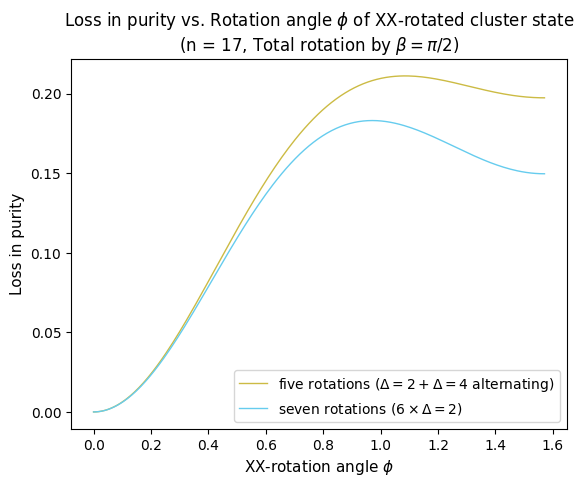

In [16]:
plt.plot(phi_ar, np.array(threerot_times2_purity_ar), "-", label=r"five rotations ($\Delta=2 + \Delta= 4$ alternating)", color=colors[3], linewidth=1)
plt.plot(phi_ar, np.array(fourrot_times2_purity_ar), "-", label=r"seven rotations ($6 \times \Delta=2$)", color=colors[4], linewidth=1)
# plt.plot(phi_ar, np.array(fourrot_times2_purity_ar) - np.array(threerot_times2_purity_ar), "-", label="difference", linewidth=1)
plt.ylabel("Loss in purity", size=11)
plt.xlabel(r"XX-rotation angle $\phi$", size=11)
plt.legend(loc="best", fontsize=10)
plt.title(r"Loss in purity vs. Rotation angle $\phi$ of XX-rotated cluster state" + "\n" + r"(n = 17, Total rotation by $\beta=\pi/2$)")
plt.savefig("figures/LP17qubitcomparison_jan2026.pdf", bbox_inches = "tight")